### GPU programming for the urban analysis

Zhanchao Yang

Assignment at the end

#### Step 1. Prepare the modules

In [1]:
!pip install pycuda
!pip install rasterio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 12.1 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp313-cp313-linux_x86_64.whl size=5281390 sha256=b3404bbc827b008348d6eaa76eab43b659397e1994615a0f14178667cf9b4401
  Stored in directory: /root/.cache/pip/wheels/ce/26/46/c519675fcb0e5e17bab8e85b6676528c40d12d794182340e85
Successfully built pycuda


In [3]:
from pycuda.compiler import SourceModule
import pycuda
from pycuda import gpuarray
from pycuda import compiler
import pycuda.autoinit             # PyCuda autoinit
import pycuda.driver as cuda       # PyCuda In, Out helpers
import os, os.path
import rasterio as rio
from osgeo import gdal
from osgeo.gdalconst import *
import numpy as np
import rasterio
import time
import math
# Load the Drive helper and mount
from google.colab import drive
import matplotlib.cm as colormap   # Library to plot
import numpy                       # Fast math library
import matplotlib.image as mpimg       # reading images to numpy arrays
import matplotlib.pyplot as plt        # to plot any graph
import scipy.ndimage as ndi            # to determine shape centrality
# matplotlib setup

%matplotlib inline
from pylab import rcParams
rcParams['figure.figsize'] = (8, 8)      # setting default size of plots


Mount to your Google Drive, you can download the digital surface model from [here](https://drive.google.com/file/d/1eEdw7mZ9XOGN6DNQMdiYJoDXkERV0e0n/view?usp=drive_link).

In [4]:

# replace "deeplearn-city/treepedia-workshop" by your own drive path
dsm_file = "/content/data/row11-col17.tif"
os.path.exists(dsm_file)

dsm_dataset = rio.open(dsm_file)

dsm_bounds = dsm_dataset.bounds
dsm_img = dsm_dataset.read(1)
print('The dsm bound is:', dsm_bounds)


transform = dsm_dataset.transform

# The pixel width and height (scale) can be found as follows:
pixel_width = transform[0]  # Scale in the x-direction
pixel_height = -transform[4]  # Scale in the y-direction (usually negative)

# You can calculate a unified scale if needed (average or reciprocal)
scale = 1 / pixel_width  # This will give you a scale factor


The dsm bound is: BoundingBox(left=2712748.0, bottom=259294.0, right=2717948.0, top=264494.0)


#### 2. Advanced: Compute the shadow distribution

In [10]:
# Define the CUDA kernel for the shadow calculation
kernel_shadow = """
#define PI 3.1415926

__global__ void calculate_shadow(float *dsm, bool *shadow, int width, int height, float cell_size, float sun_azimuth, float sun_elevation) {
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;
    // Check if the thread is within the bounds of the image
    if (x >= width || y >= height)
        return;

    int idx = y * width + x;

    // Convert sun azimuth and elevation to radians
    float azimuth_rad = sun_azimuth * 3.14159 / 180.0;
    float elevation_rad = sun_elevation * 3.14159 / 180.0;

    // Direction of the shadow ray based on sun azimuth
    float dx = sin(azimuth_rad);
    float dy = -cos(azimuth_rad); //because the azimuth start from the north, anti-clockwise
    float dz = tan(elevation_rad);

    // Initial height at the current pixel
    float initial_height = dsm[idx];
    bool in_shadow = false;

    // Trace the shadow ray
    for (float t = cell_size; t < 2000.0f; t += cell_size) { // Limit tracing distance
        int x_offset = x + int(dx * t / cell_size);
        int y_offset = y + int(dy * t / cell_size);

        if (x_offset < 0 || x_offset >= width || y_offset < 0 || y_offset >= height)
            break;  // Out of bounds

        int offset_idx = y_offset * width + x_offset;

        // Calculate height along the ray
        float height_along_ray = initial_height + dz * t;

        // Check if there is a higher point along the path
        if (dsm[offset_idx] > height_along_ray) {
            in_shadow = true;
            break;
        }
    }

    // Store shadow result: 1 for shadow, 0 for no shadow
    shadow[idx] = in_shadow;
}
"""

# Compile the kernel
mod = SourceModule(kernel_shadow)
calculate_shadows = mod.get_function("calculate_shadow")

In [11]:
# Prepare parameters and allocate memory
height, width = dsm_img.shape

# Allocate memory for input DSM and output shadow map
d_dsm = cuda.mem_alloc(dsm_img.nbytes)
d_shadow = cuda.mem_alloc(dsm_img.nbytes)  # Shadow result (boolean)

# Copy DSM to GPU
cuda.memcpy_htod(d_dsm, dsm_img)

# Initialize shadow output array on CPU
shadow_result = np.zeros_like(dsm_img, dtype=bool)

In [12]:
# Sun parameters (angles in degrees), you can get the sun positions using the tool of https://gml.noaa.gov/grad/solcalc/azel.html
# you can also find the Python module to do it.
sun_azimuth = 45.0       # Example: 45 degrees from the north
sun_elevation = 60.0     # Example: 30 degrees above the horizon
cell_size = 1.0          # Adjust based on DSM resolution, e.g., 1 meter per pixel


# Define block and grid size
block_size = (16, 16, 1)
grid_size = (int(np.ceil(width / block_size[0])), int(np.ceil(height / block_size[1])))


# Convert sun angles to float32 and launch the kernel
calculate_shadows(
    d_dsm, d_shadow, np.int32(width), np.int32(height),
    np.float32(cell_size), np.float32(sun_azimuth), np.float32(sun_elevation),
    block=block_size, grid=grid_size
)


In [13]:
# Copy the shadow results back to the host
cuda.memcpy_dtoh(shadow_result, d_shadow)

# Free GPU memory
d_dsm.free()
d_shadow.free()

In [14]:
binary_shadow = shadow_result.astype(np.uint8)  # 1 for True (shadow), 0 for False (non-shadow)


In [15]:
shadow_result

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])

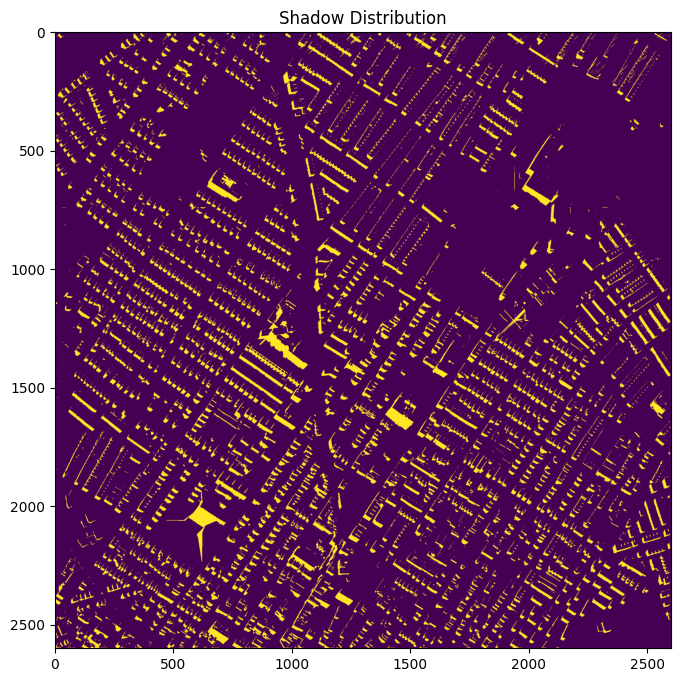

In [16]:
# Display the binary shadow image
plt.imshow(shadow_result)
# plt.colorbar(label="Shadow (1=True, 0=False)")
plt.title("Shadow Distribution")
plt.show()

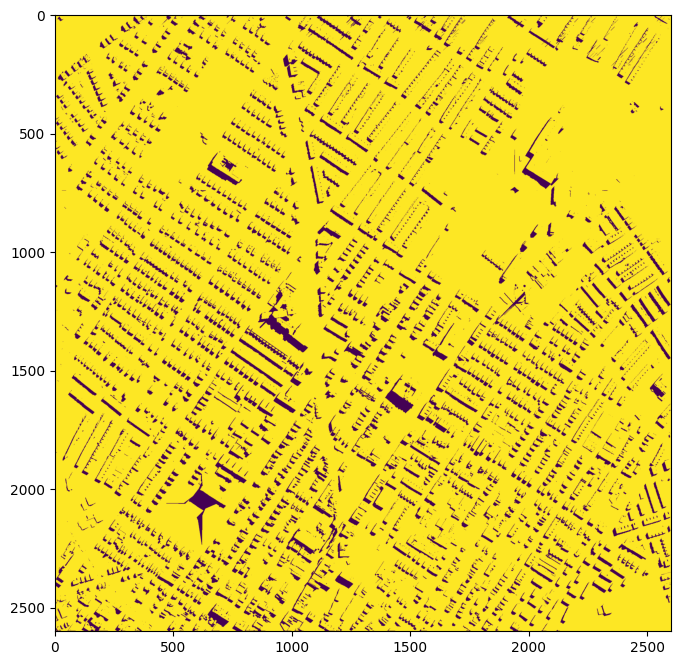

In [17]:
import matplotlib.pyplot as plt

plt.imshow(binary_shadow==0)
# plt.colorbar(label="Shadow (1=True, 0=False)")
# plt.title("Shadow Distribution")
plt.show()

## Homework 3 Shadow analysis

Conduct the shadow analysis using the provided geotiff image. Gnerate the shadow maps on a certain day from 8 am to 5pm each hour. You can calculate the solar position using the NOAA solar calculator tool (https://gml.noaa.gov/grad/solcalc/azel.html).  In the end please export your results as png/jpg files and combine those shadow maps for each other into a GIF.

Please upload your co-lab link to canvas or send me your link.

Hint: You can use the loop to calculate the shadow and export those shadow maps, like

Combine those png into GIF.


Please submit your homework before **Oct 24th, 2025**.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pycuda.driver as cuda
from PIL import Image
import os
# Using October 5 NOAA data for City of Philadelphia
# 1. Define estimated solar positions: (hour, elevation, azimuth)
solar_pos_lst = [
    (8, 21.06, 116.13),
    (9, 30.74, 128.81),
    (10, 38.64, 144.27),
    (11, 43.76, 162.99),
    (12, 45.06, 183.89),
    (13, 42.23, 204.23),
    (14, 35.94, 221.74),
    (15, 27.26, 236.06),
    (16, 17.12, 247.91),
    (17, 6.2, 258.25)
]

In [20]:
# 2. Re-allocate memory on the GPU (since it was freed in previous cells)
d_dsm = cuda.mem_alloc(dsm_img.nbytes)
cuda.memcpy_htod(d_dsm, dsm_img)
d_shadow = cuda.mem_alloc(dsm_img.nbytes)

shadow_result = np.zeros_like(dsm_img, dtype=bool)
image_filenames = []

In [21]:
# 3. Loop through solar positions to calculate shadows and save images
print("Calculating hourly shadows...")
for (hour, sunele, azimuth) in solar_pos_lst:
    # Run the kernel
    calculate_shadows(
        d_dsm, d_shadow, np.int32(width), np.int32(height),
        np.float32(cell_size), np.float32(azimuth), np.float32(sunele),
        block=block_size, grid=grid_size
    )

    # Copy result back to CPU
    cuda.memcpy_dtoh(shadow_result, d_shadow)

    # Save image as PNG
    filename = f"shadow_map_{hour:02d}00.png"
    plt.imsave(filename, shadow_result, cmap="gray")
    image_filenames.append(filename)
    print(f"Saved {filename}")

# Free GPU memory
d_dsm.free()
d_shadow.free()

Calculating hourly shadows...
Saved shadow_map_0800.png
Saved shadow_map_0900.png
Saved shadow_map_1000.png
Saved shadow_map_1100.png
Saved shadow_map_1200.png
Saved shadow_map_1300.png
Saved shadow_map_1400.png
Saved shadow_map_1500.png
Saved shadow_map_1600.png
Saved shadow_map_1700.png


In [22]:
# 4. Combine PNGs into an animated GIF
print("\nCreating GIF...")
frames = [Image.open(image) for image in image_filenames]

gif_filename = "shadow_animation.gif"
frames[0].save(
    gif_filename,
    format="GIF",
    append_images=frames[1:],
    save_all=True,
    duration=500,  # Duration of each frame in milliseconds
    loop=0
)

print(f"Success! You can download '{gif_filename}' from the Colab file browser.")


Creating GIF...
Success! You can download 'shadow_animation.gif' from the Colab file browser.
